<a href="https://colab.research.google.com/github/Juliana-Amorim/science-des-donn-es--ducation/blob/main/OLS%20et%20transformation%20de%20Box-Cox%20pour%20distribution%20non%20normale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mca_lycees_2023.xlsx to mca_lycees_2023.xlsx


In [ ]:
import pandas as pd
table_ols = pd.read_excel('mca_lycees_2023.xlsx')

In [ ]:
print(table_ols)

      num_ligne Rentrée scolaire    Académie       UAI  \
0          1128        2023-2024    GRENOBLE  0382895R   
1          1677        2023-2024  NANCY-METZ  0573320Z   
2          1836        2023-2024       LILLE  0595867G   
3          1848        2023-2024       LILLE  0597005U   
4          1977        2023-2024       LILLE  0623902E   
...         ...              ...         ...       ...   
1538       3071        2023-2024       DIJON  0890003V   
1539       3324        2023-2024     CRETEIL  0932667U   
1540       3490        2023-2024  GUADELOUPE  9710884J   
1541       3524        2023-2024  MARTINIQUE  9720692V   
1542       3603        2023-2024     MAYOTTE  9760127J   

                                 Nom de l'établissement Type de lycée  \
0                           LYCEE POLYVALENT PH DELORME           LPO   
1     LYCEE POLYVALENT RAYMOND MONDON LYCEE DES METI...           LPO   
2     LYCEE GENERAL ET TECHNOLOGIQUE INTERNATIONAL M...          LEGT   
3          

In [ ]:
table_ols = table_ols.drop(columns=['num_ligne', 'Rentrée scolaire', 'Académie', "Nom de l'établissement", 'Type de lycée'])

In [ ]:
table_ols = table_ols[table_ols['élèves.filles'] != 0]

In [ ]:
table_ols['prop_filles'] = table_ols['élèves.filles']/table_ols['Nombre.élèves']

In [ ]:
print(table_ols)

           UAI  IPS voie GT  Taux d'accès 2nde-bac  Nombre.élèves  \
0     0382895R        107.7                     85            996   
2     0595867G        106.4                     78           1337   
3     0597005U        102.7                     86            511   
4     0623902E         97.5                     74            507   
5     0940743X         97.1                     85           1021   
...        ...          ...                    ...            ...   
1538  0890003V        118.4                     89            860   
1539  0932667U         80.9                     90            732   
1540  9710884J        101.4                     90            483   
1541  9720692V        105.1                     97            261   
1542  9760127J         80.9                     76           2359   

      élèves.filles  élèves.garçons  prop_filles  
0               385             323     0.386546  
2               773             424     0.578160  
3               24

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving regions_academiques.xlsx to regions_academiques.xlsx


In [ ]:
regions = pd.read_excel('regions_academiques.xlsx')

In [ ]:
print(regions)

     Rentrée scolaire    Académie       UAI  \
0           2023-2024    GRENOBLE  0382895R   
1           2023-2024  NANCY-METZ  0573320Z   
2           2023-2024       LILLE  0595867G   
3           2023-2024       LILLE  0597005U   
4           2023-2024       LILLE  0623902E   
...               ...         ...       ...   
1538        2023-2024       DIJON  0890003V   
1539        2023-2024     CRETEIL  0932667U   
1540        2023-2024  GUADELOUPE  9710884J   
1541        2023-2024  MARTINIQUE  9720692V   
1542        2023-2024     MAYOTTE  9760127J   

                                 Nom de l'établissement Secteur Type de lycée  \
0                           LYCEE POLYVALENT PH DELORME  public           LPO   
1     LYCEE POLYVALENT RAYMOND MONDON LYCEE DES METI...  public           LPO   
2     LYCEE GENERAL ET TECHNOLOGIQUE INTERNATIONAL M...  public          LEGT   
3                        LYCEE POLYVALENT DU VAL DE LYS  public           LPO   
4                 LYCEE POLYVA

In [ ]:
regions = regions.drop(columns=['Rentrée scolaire', 'Académie', "Nom de l'établissement", 'Secteur', 'Type de lycée', 'IPS voie GT', "Taux d'accès 2nde-bac"])

In [ ]:
table_ols = pd.merge(table_ols, regions, on='UAI', how='inner')

In [ ]:
table_ols = table_ols.drop(columns=['Nombre.élèves', 'élèves.filles', 'élèves.garçons'])

In [ ]:
print(table_ols)

           UAI  IPS voie GT  Taux d'accès 2nde-bac  prop_filles  \
0     0382895R        107.7                     85     0.386546   
1     0595867G        106.4                     78     0.578160   
2     0597005U        102.7                     86     0.479452   
3     0623902E         97.5                     74     0.378698   
4     0940743X         97.1                     85     0.439765   
...        ...          ...                    ...          ...   
1508  0890003V        118.4                     89     0.608140   
1509  0932667U         80.9                     90     0.422131   
1510  9710884J        101.4                     90     0.385093   
1511  9720692V        105.1                     97     0.547893   
1512  9760127J         80.9                     76     0.435354   

                       Region  
0        Auvergne-Rhone-Alpes  
1             Hauts-de-France  
2             Hauts-de-France  
3             Hauts-de-France  
4               Ile-de-France  
...

In [ ]:
table_ols.to_excel('table_ols.xlsx')

In [ ]:
table_ols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UAI                    1513 non-null   object 
 1   IPS voie GT            1513 non-null   float64
 2   Taux d'accès 2nde-bac  1513 non-null   int64  
 3   prop_filles            1513 non-null   float64
 4   Region                 1513 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 59.2+ KB


In [ ]:
table_ols.describe()

,IPS voie GT,Taux d'accès 2nde-bac,prop_filles
count,1513.000000,1513.000000,1513.000000
mean,110.560013,83.863847,0.439255
std,13.301347,6.251981,0.101726
min,62.500000,43.000000,0.017778
25%,102.900000,81.000000,0.404221
50%,110.300000,85.000000,0.452774
75%,118.200000,88.000000,0.499142
max,162.600000,100.000000,0.757774


In [ ]:
table_ols.groupby('Region').describe()

IPS voie GT                                         \
                                 count        mean        std    min      25%   
Region                                                                          
Auvergne-Rhone-Alpes             172.0  113.579651  11.880216   81.6  106.250   
Bourgogne-Franche-Comté           70.0  110.788571   7.641431   96.3  105.400   
Bretagne                          61.0  116.813115   8.177723  101.5  111.500   
Caraibes                          41.0   99.214634  11.882983   76.3   91.700   
Centre-Val-de-Loire               50.0  110.976000   7.616512   92.1  105.725   
Corse                              9.0  107.633333   6.672706   99.6  101.300   
Grand-Est                        135.0  107.300000   9.908590   73.4  100.300   
Hauts-de-France                  127.0  102.990551  11.309881   72.7   95.400   
Ile-de-France                    303.0  112.987129  18.121985   77.3   99.500   
La Reunion                        29.0   95.837931   8.710356   80.5   89.300   
Mayotte                           10.0   74.800000   9.402955   62.5   67.325   
Normandie                         80.0  108.985000   9.557290   86.9  103.400   
Nouvelle-Aquitaine               132.0  113.665152   8.611265   89.7  108.450   
Occitane                         128.0  114.432031   9.688844   96.8  107.500   
Pays de la Loire                  67.0  114.832836  10.704918   93.8  107.900   
Provence-Alpes-Côte d'Azur        99.0  109.940404  12.437467   73.6  102.900   

                                                   Taux d'accès 2nde-bac  \
                               50%      75%    max                 count   
Region                                                                     
Auvergne-Rhone-Alpes        113.65  121.000  147.6                 172.0   
Bourgogne-Franche-Comté     110.35  115.800  132.2                  70.0   
Bretagne                    117.30  121.100  137.0                  61.0   
Caraibes                    102.20  107.200  118.1                  41.0   
Centre-Val-de-Loire         111.35  114.800  132.9                  50.0   
Corse                       104.70  113.500  116.2                   9.0   
Grand-Est                   107.10  113.950  132.1                 135.0   
Hauts-de-France             102.90  110.000  132.1                 127.0   
Ile-de-France               112.70  125.450  162.6                 303.0   
La Reunion                   94.90  101.600  113.7                  29.0   
Mayotte                      76.45   81.350   87.4                  10.0   
Normandie                   108.80  113.775  142.4                  80.0   
Nouvelle-Aquitaine          112.65  119.175  138.6                 132.0   
Occitane                    112.75  119.750  139.0                 128.0   
Pays de la Loire            113.20  121.600  145.9                  67.0   
Provence-Alpes-Côte d'Azur  109.90  118.150  146.4                  99.0   

                                       ...               prop_filles  \
                                 mean  ...    75%    max       count   
Region                                 ...                             
Auvergne-Rhone-Alpes        84.180233  ...  88.00   94.0       172.0   
Bourgogne-Franche-Comté     85.657143  ...  88.00   94.0        70.0   
Bretagne                    83.491803  ...  88.00   94.0        61.0   
Caraibes                    82.609756  ...  90.00   97.0        41.0   
Centre-Val-de-Loire         84.260000  ...  87.00   92.0        50.0   
Corse                       86.555556  ...  91.00   92.0         9.0   
Grand-Est                   83.933333  ...  89.00  100.0       135.0   
Hauts-de-France             81.062992  ...  86.00   99.0       127.0   
Ile-de-France               85.438944  ...  90.00  100.0       303.0   
La Reunion                  82.379310  ...  86.00   91.0        29.0   
Mayotte                     71.000000  ...  79.00   85.0        10.0   
Normandie                   82.687

In [ ]:
from sklearn.preprocessing import LabelEncoder
table_ols['Region_numero'] = LabelEncoder().fit_transform(table_ols['Region'])
table_ols['Region_numero'] = table_ols['Region_numero'] + 1

In [ ]:
print(table_ols)

           UAI  IPS voie GT  Taux d'accès 2nde-bac  prop_filles  \
0     0382895R        107.7                     85     0.386546   
1     0595867G        106.4                     78     0.578160   
2     0597005U        102.7                     86     0.479452   
3     0623902E         97.5                     74     0.378698   
4     0940743X         97.1                     85     0.439765   
...        ...          ...                    ...          ...   
1508  0890003V        118.4                     89     0.608140   
1509  0932667U         80.9                     90     0.422131   
1510  9710884J        101.4                     90     0.385093   
1511  9720692V        105.1                     97     0.547893   
1512  9760127J         80.9                     76     0.435354   

                       Region  Region_numero  
0        Auvergne-Rhone-Alpes              1  
1             Hauts-de-France              8  
2             Hauts-de-France              8  
3      

In [ ]:
table_ols_dummies = pd.get_dummies(table_ols, columns=['Region'],
                                   dtype=int,
                                   drop_first=True)


table_ols_dummies = table_ols_dummies.rename(columns={
    "Taux d'accès 2nde-bac": "Taux_d_acces_2nde_bac",
    "IPS voie GT": "IPS_voie_GT"
})

new_column_mapping = {}
for col in table_ols_dummies.columns:
    if col.startswith('Region_'):
        cleaned_col = col.replace(" ", "_").replace("-", "_").replace("'", "").replace("`", "")
        if cleaned_col != col:
            new_column_mapping[col] = cleaned_col
table_ols_dummies = table_ols_dummies.rename(columns=new_column_mapping)

table_ols_dummies

,UAI,IPS_voie_GT,Taux_d_acces_2nde_bac,prop_filles,Region_numero,Region_Bourgogne_Franche_Comté,Region_Bretagne,Region_Caraibes,Region_Centre_Val_de_Loire,Region_Corse,Region_Grand_Est,Region_Hauts_de_France,Region_Ile_de_France,Region_La_Reunion,Region_Mayotte,Region_Normandie,Region_Nouvelle_Aquitaine,Region_Occitane,Region_Pays_de_la_Loire,Region_Provence_Alpes_Côte_dAzur
0,0382895R,107.7,85,0.386546,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0595867G,106.4,78,0.578160,8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0597005U,102.7,86,0.479452,8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0623902E,97.5,74,0.378698,8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0940743X,97.1,85,0.439765,9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,0890003V,118.4,89,0.608140,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1509,0932667U,80.9,90,0.422131,9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1510,9710884J,101.4,90,0.385093,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1511,9720692V,105.1,97,0.547893,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
import statsmodels.formula.api as sm

formula = "Taux_d_acces_2nde_bac ~ IPS_voie_GT + prop_filles + " \
          "Region_Bourgogne_Franche_Comté + Region_Bretagne + Region_Caraibes + " \
          "Region_Centre_Val_de_Loire + Region_Corse + Region_Grand_Est + " \
          "Region_Hauts_de_France + Region_Ile_de_France + Region_La_Reunion + " \
          "Region_Mayotte + Region_Normandie + Region_Nouvelle_Aquitaine + " \
          "Region_Occitane + Region_Pays_de_la_Loire + Region_Provence_Alpes_Côte_dAzur"

modelo_table_ols_dummies = sm.ols(formula, data=table_ols_dummies).fit()

In [ ]:
modelo_table_ols_dummies.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Taux_d_acces_2nde_bac   R-squared:                       0.318
Model:                               OLS   Adj. R-squared:                  0.310
Method:                    Least Squares   F-statistic:                     40.93
Date:                   Tue, 31 Mar 2026   Prob (F-statistic):          4.26e-111
Time:                           10:21:27   Log-Likelihood:                -4630.4
No. Observations:                   1513   AIC:                             9297.
Df Residuals:                       1495   BIC:                             9393.
Df Model:                             17                                         
Covariance Type:               nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           54.9355      1.330     41.317      0.000      52.327      57.544
IPS_voie_GT                          0.2132      0.011     18.634      0.000       0.191       0.236
prop_filles                         11.4370      1.377      8.307      0.000       8.736      14.138
Region_Bourgogne_Franche_Comté       1.8849      0.738      2.555      0.011       0.438       3.332
Region_Bretagne                     -1.3917      0.775     -1.796      0.073      -2.912       0.128
Region_Caraibes                      1.2677      0.919      1.379      0.168      -0.535       3.071
Region_Centre_Val_de_Loire           0.6296      0.835      0.754      0.451      -1.008       2.267
Region_Corse                         3.3718      1.778      1.896      0.058      -0.116       6.859
Region_Grand_Est                     1.1348      0.601      1.887      0.059      -0.045       2.314
Region_Hauts_de_France              -0.7526      0.619     -1.216      0.224      -1.967       0.462
Region_Ile_de_France                 1.5634      0.496      3.150      0.002       0.590       2.537
Region_La_Reunion                    1.9984      1.062      1.882      0.060      -0.085       4.082
Region_Mayotte                      -5.0359      1.748     -2.881      0.004      -8.464      -1.607
Region_Normandie                    -0.3990      0.705     -0.566      0.571      -1.781       0.983
Region_Nouvelle_Aquitaine           -0.8672      0.601     -1.442      0.149      -2.047       0.312
Region_Occitane                     -0.7120      0.606     -1.174      0.241      -1.902       0.478
Region_Pays_de_la_Loire             -0.7391      0.748     -0.988      0.323      -2.207       0.729
Region_Provence_Alpes_Côte_dAzur     0.9875      0.656      1.504      0.133      -0.300       2.275
==============================================================================
Omnibus:                      299.640   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1089.926
Skew:                          -0.935   Prob(JB):                    2.12e-237
Kurtosis:                       6.713   Cond. No.                     1.72e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
table_ols_dummies['fitted'] = modelo_table_ols_dummies.fittedvalues
table_ols_dummies

,UAI,IPS_voie_GT,Taux_d_acces_2nde_bac,prop_filles,Region_numero,Region_Bourgogne_Franche_Comté,Region_Bretagne,Region_Caraibes,Region_Centre_Val_de_Loire,Region_Corse,...,Region_Hauts_de_France,Region_Ile_de_France,Region_La_Reunion,Region_Mayotte,Region_Normandie,Region_Nouvelle_Aquitaine,Region_Occitane,Region_Pays_de_la_Loire,Region_Provence_Alpes_Côte_dAzur,fitted
0,0382895R,107.7,85,0.386546,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,82.313984
1,0595867G,106.4,78,0.578160,8,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,83.475710
2,0597005U,102.7,86,0.479452,8,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,81.558086
3,0623902E,97.5,74,0.378698,8,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,79.297320
4,0940743X,97.1,85,0.439765,9,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,82.226484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,0890003V,118.4,89,0.608140,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,89.014092
1509,0932667U,80.9,90,0.422131,9,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,78.571573
1510,9710884J,101.4,90,0.385093,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,82.222114
1511,9720692V,105.1,97,0.547893,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,84.872752


In [ ]:
region_names = [
    "Auvergne-Rhône-Alpes",
    "Bourgogne-Franche-Comté",
    "Bretagne",
    "Caraïbes",
    "Centre-Val de Loire",
    "Corse",
    "Grand Est",
    "Hauts-de-France",
    "Île-de-France",
    "La Réunion",
    "Mayotte",
    "Normandie",
    "Nouvelle-Aquitaine",
    "Occitanie",
    "Pays de la Loire",
    "Provence-Alpes-Côte d’Azur"
]

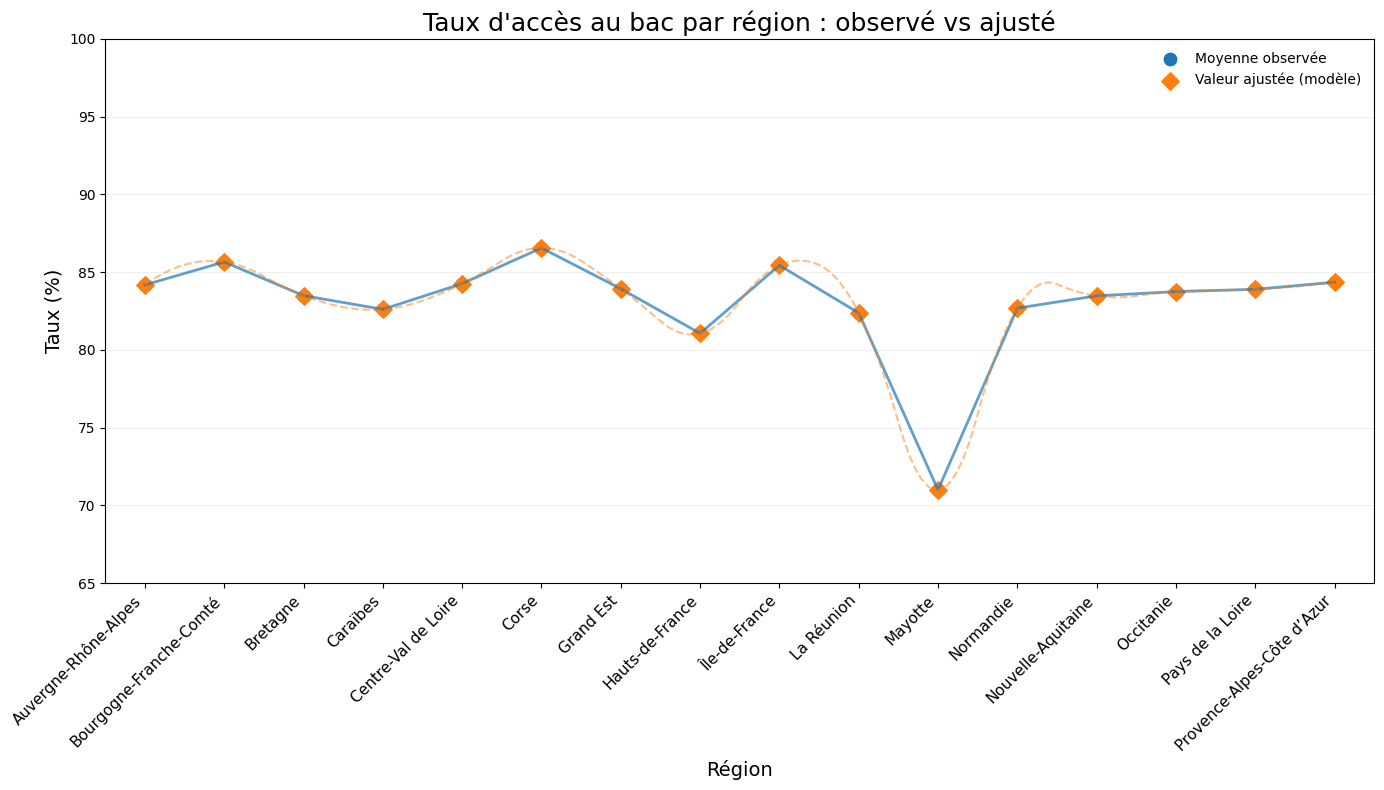

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import interpolate

plt.figure(figsize=(14,8))

agg = (table_ols_dummies
       .groupby('Region_numero')
       .agg(
           mean_obs=('Taux_d_acces_2nde_bac','mean'),
           mean_fit=('fitted','mean')
       )
       .reset_index())

x = agg['Region_numero']
y_obs = agg['mean_obs']
y_fit = agg['mean_fit']

tck = interpolate.splrep(x, y_fit, k=2)
xnew = np.linspace(x.min(), x.max(), 300)
ynew = interpolate.splev(xnew, tck)

plt.scatter(x, y_obs, s=80, label='Moyenne observée')

plt.scatter(x, y_fit, s=80, marker='D', label='Valeur ajustée (modèle)')


plt.plot(x, y_fit, linewidth=2, alpha=0.7)


plt.plot(xnew, ynew, linestyle='--', alpha=0.5)


plt.ylim(65, 100)
plt.xlim(x.min()-0.5, x.max()+0.5)


plt.xticks(
    x,
    region_names,
    rotation=45,
    ha='right',
    fontsize=11
)
plt.yticks(np.arange(65, 101, 5))


plt.grid(axis='y', alpha=0.2)
plt.legend(frameon=False)

plt.title("Taux d'accès au bac par région : observé vs ajusté", fontsize=18)
plt.xlabel("Région", fontsize=14)
plt.ylabel("Taux (%)", fontsize=14)

plt.tight_layout()
plt.show()

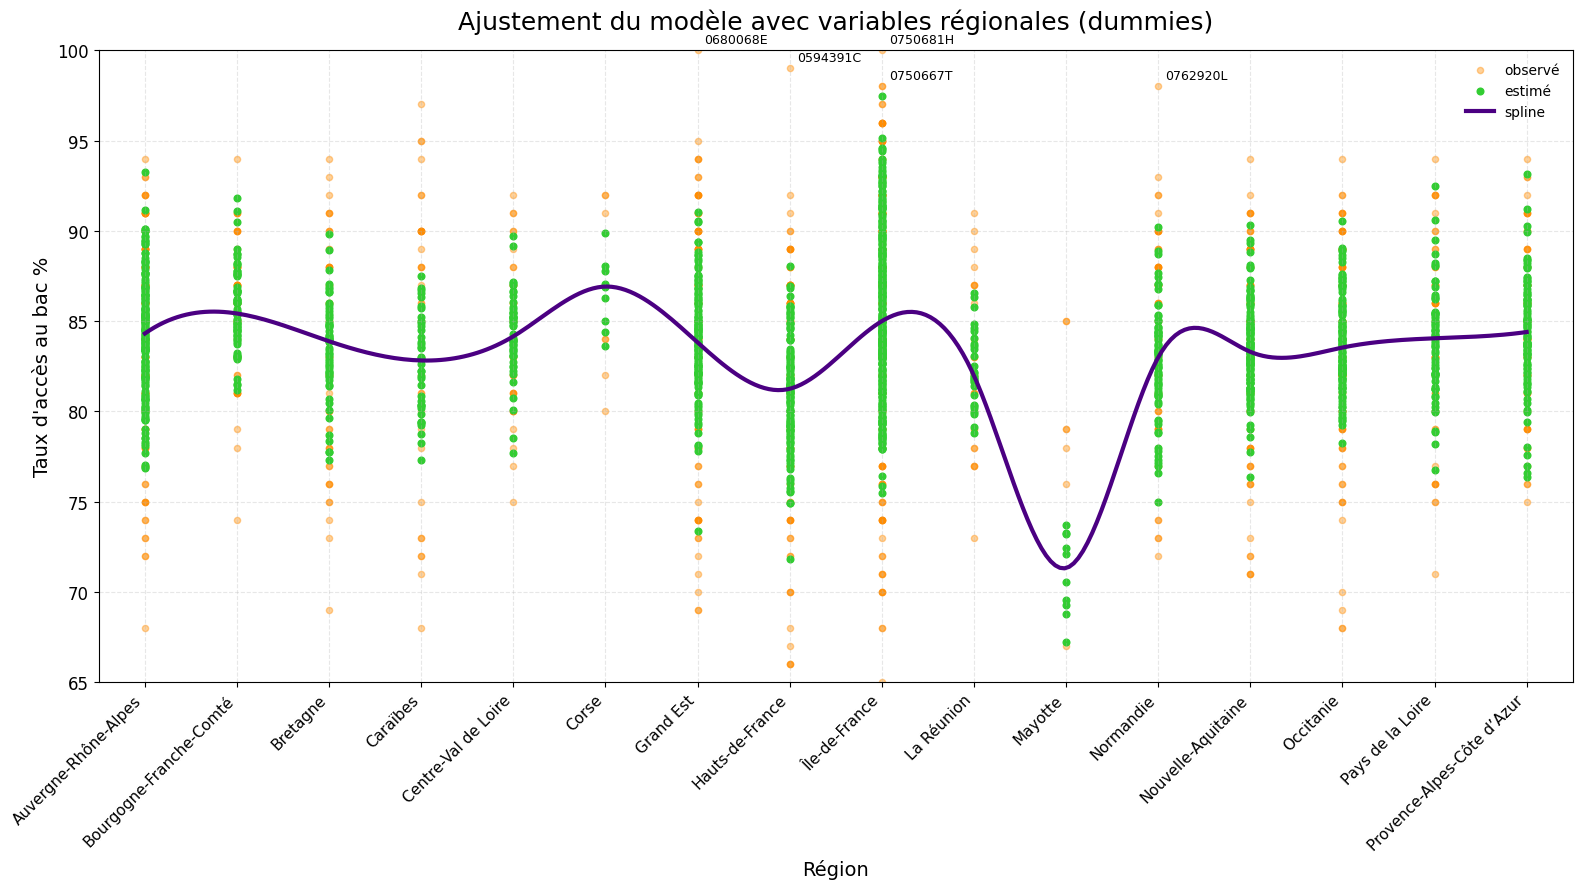

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate

plt.figure(figsize=(16,9))

table2 = table_ols_dummies[['Region_numero',
                            'fitted']].groupby(['Region_numero']).\
        median().reset_index()

x = table2['Region_numero']
y = table2['fitted']

tck = interpolate.splrep(x, y, k=3)
xnew = np.linspace(x.min(), x.max(), 300)
ynew = interpolate.splev(xnew, tck)

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        offset = 0
        while ax.texts:
            overlapping = False
            for text in ax.texts:
                overlapping |= text.get_position()[0] == (point['x'] + 0.05) and\
                    text.get_position()[1] == (point['y'] - 0.05 + offset)
            if overlapping:
                offset += 0.15
            else:
                break
        ax.annotate(str(point['val']) + " " + str(point['y']),
                    (point['x'] + 0.05,
                     point['y'] - 0.05 + offset),
                    fontsize=11)

top = table_ols_dummies.nlargest(5, 'Taux_d_acces_2nde_bac')
bottom = table_ols_dummies.nsmallest(5, 'Taux_d_acces_2nde_bac')
subset = pd.concat([top, bottom])

for _, row in subset.iterrows():
    plt.annotate(row['UAI'],
                 (row['Region_numero'], row['Taux_d_acces_2nde_bac']),
                 xytext=(5,5),
                 textcoords='offset points',
                 fontsize=9)

plt.scatter(table_ols_dummies['Region_numero'],
            table_ols_dummies['Taux_d_acces_2nde_bac'], color='darkorange', s=20, alpha=0.4, label="observé")

plt.scatter(table_ols_dummies['Region_numero'],
            table_ols_dummies['fitted'], color='limegreen', s=23, label='estimé')

plt.plot(xnew, ynew, color='indigo', linewidth=3, label='spline')

plt.title('Ajustement du modèle avec variables régionales (dummies)', fontsize=18, pad=15)
plt.xlabel('Région', fontsize=14)
plt.ylabel("Taux d'accès au bac %", fontsize=14)
plt.ylim(65, 100)
plt.xlim(x.min() - 0.5, x.max() + 0.5)

plt.xticks(
    x,
    region_names,
    rotation=45,
    ha='right',
    fontsize=11
)

plt.yticks(
    np.arange(65, 101, 5),
    fontsize=12
)

plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.show()

In [ ]:
!pip install statstests
from statstests.tests import shapiro_francia

In [ ]:
test_sf = shapiro_francia(modelo_table_ols_dummies.resid)
test_sf = test_sf.items()
method, statistics_W, statistics_z, p = test_sf
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05
if p[1] > alpha:
	print('Non rejet de H0 - distribution normale')
else:
	print('Rejet de H0 – distribution non normale')

method  :  Shapiro-Francia normality test
statistics W  :  0.9523356906818563
statistics z  :  9.029911448366699
p-value  :  8.590538481894558e-20
Statistics W=0.95234, p-value=0.000000
Rejet de H0 – distribution non normale


In [ ]:
# transformation de Box-Cox pour distribution non normale

from scipy.stats import boxcox

yast, lmbda = boxcox(table_ols_dummies['Taux_d_acces_2nde_bac'])
lmbda

np.float64(4.381809234161132)

In [ ]:
table_ols_dummies['bc_Taux_d_acces_2nde_bac'] = yast
table_ols_dummies

,UAI,IPS_voie_GT,Taux_d_acces_2nde_bac,prop_filles,Region_numero,Region_Bourgogne_Franche_Comté,Region_Bretagne,Region_Caraibes,Region_Centre_Val_de_Loire,Region_Corse,...,Region_Ile_de_France,Region_La_Reunion,Region_Mayotte,Region_Normandie,Region_Nouvelle_Aquitaine,Region_Occitane,Region_Pays_de_la_Loire,Region_Provence_Alpes_Côte_dAzur,fitted,bc_Taux_d_acces_2nde_bac
0,0382895R,107.7,85,0.386546,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,82.313984,6.496691e+07
1,0595867G,106.4,78,0.578160,8,0,0,0,0,0,...,0,0,0,0,0,0,0,0,83.475710,4.458042e+07
2,0597005U,102.7,86,0.479452,8,0,0,0,0,0,...,0,0,0,0,0,0,0,0,81.558086,6.838325e+07
3,0623902E,97.5,74,0.378698,8,0,0,0,0,0,...,0,0,0,0,0,0,0,0,79.297320,3.539675e+07
4,0940743X,97.1,85,0.439765,9,0,0,0,0,0,...,1,0,0,0,0,0,0,0,82.226484,6.496691e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,0890003V,118.4,89,0.608140,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,89.014092,7.946972e+07
1509,0932667U,80.9,90,0.422131,9,0,0,0,0,0,...,1,0,0,0,0,0,0,0,78.571573,8.345731e+07
1510,9710884J,101.4,90,0.385093,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,82.222114,8.345731e+07
1511,9720692V,105.1,97,0.547893,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,84.872752,1.158781e+08


In [ ]:
!pip install itables
import itables
itables.show(table_ols_dummies)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.3 MB/s eta 0:00:00


Loading ITables v2.7.3 from the internet... (need help?)


In [ ]:
formula_bc = "bc_Taux_d_acces_2nde_bac ~ IPS_voie_GT + prop_filles + " \
             "Region_Bourgogne_Franche_Comté + Region_Bretagne + Region_Caraibes + " \
             "Region_Centre_Val_de_Loire + Region_Corse + Region_Grand_Est + " \
             "Region_Hauts_de_France + Region_Ile_de_France + Region_La_Reunion + " \
             "Region_Mayotte + Region_Normandie + Region_Nouvelle_Aquitaine + " \
             "Region_Occitane + Region_Pays_de_la_Loire + Region_Provence_Alpes_Côte_dAzur"

table_ols_bc = sm.ols(formula_bc, data=table_ols_dummies).fit()
table_ols_bc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     bc_Taux_d_acces_2nde_bac   R-squared:                       0.334
Model:                                  OLS   Adj. R-squared:                  0.326
Method:                       Least Squares   F-statistic:                     44.10
Date:                      Tue, 31 Mar 2026   Prob (F-statistic):          8.33e-119
Time:                              10:32:26   Log-Likelihood:                -27151.
No. Observations:                      1513   AIC:                         5.434e+04
Df Residuals:                          1495   BIC:                         5.443e+04
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                        -2.697e+07   3.87e+06     -6.966      0.000   -3.46e+07   -1.94e+07
IPS_voie_GT                       6.848e+05   3.33e+04     20.555      0.000    6.19e+05     7.5e+05
prop_filles                       2.958e+07   4.01e+06      7.377      0.000    2.17e+07    3.74e+07
Region_Bourgogne_Franche_Comté    5.616e+06   2.15e+06      2.614      0.009     1.4e+06    9.83e+06
Region_Bretagne                  -4.112e+06   2.26e+06     -1.822      0.069   -8.54e+06    3.14e+05
Region_Caraibes                   8.421e+06   2.68e+06      3.146      0.002    3.17e+06    1.37e+07
Region_Centre_Val_de_Loire        1.388e+06   2.43e+06      0.571      0.568   -3.38e+06    6.16e+06
Region_Corse                       1.11e+07   5.18e+06      2.143      0.032    9.41e+05    2.13e+07
Region_Grand_Est                  4.652e+06   1.75e+06      2.656      0.008    1.22e+06    8.09e+06
Region_Hauts_de_France           -8.791e+05    1.8e+06     -0.488      0.626   -4.42e+06    2.66e+06
Region_Ile_de_France              6.664e+06   1.45e+06      4.611      0.000    3.83e+06     9.5e+06
Region_La_Reunion                 6.179e+06   3.09e+06      1.998      0.046    1.12e+05    1.22e+07
Region_Mayotte                   -1.448e+06   5.09e+06     -0.284      0.776   -1.14e+07    8.54e+06
Region_Normandie                  5.033e+05   2.05e+06      0.245      0.806   -3.52e+06    4.53e+06
Region_Nouvelle_Aquitaine         -2.92e+06   1.75e+06     -1.667      0.096   -6.35e+06    5.15e+05
Region_Occitane                  -2.255e+06   1.77e+06     -1.277      0.202   -5.72e+06    1.21e+06
Region_Pays_de_la_Loire          -2.404e+06   2.18e+06     -1.103      0.270   -6.68e+06    1.87e+06
Region_Provence_Alpes_Côte_dAzur  2.959e+06   1.91e+06      1.548      0.122   -7.91e+05    6.71e+06
==============================================================================
Omnibus:                       39.594   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               86.105
Skew:                           0.089   Prob(JB):                     2.01e-19
Kurtosis:                       4.155   Cond. No.                     1.72e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test_sf = shapiro_francia(table_ols_bc.resid)
test_sf = test_sf.items()
method, statistics_W, statistics_z, p = test_sf
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05
if p[1] > alpha:
	print('Non rejet de H0 - distribution normale')
else:
	print('Rejet de H0 – distribution non normale')

method  :  Shapiro-Francia normality test
statistics W  :  0.9908147535378928
statistics z  :  5.15554122983604
p-value  :  1.2644969310967528e-07
Statistics W=0.99081, p-value=0.000000
Rejet de H0 – distribution non normale
